<a href="https://colab.research.google.com/github/JuliaVillaVerde/Processamentos-de-Sinais-7P./blob/main/Aula4_Processamento_de_Sinais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Questão 1 - Letra a

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Carregando o arquivo de áudio: /content/handel.wav
Taxa de amostragem: 8192 Hz
Duração do áudio: 8.92 segundos

Realizando compressão e gerando gráficos e áudios:

Processando compressão de 99.5%
Processando compressão de 99.0%
Processando compressão de 90.0%
Processando compressão de 75.0%
Processando compressão de 50.0%


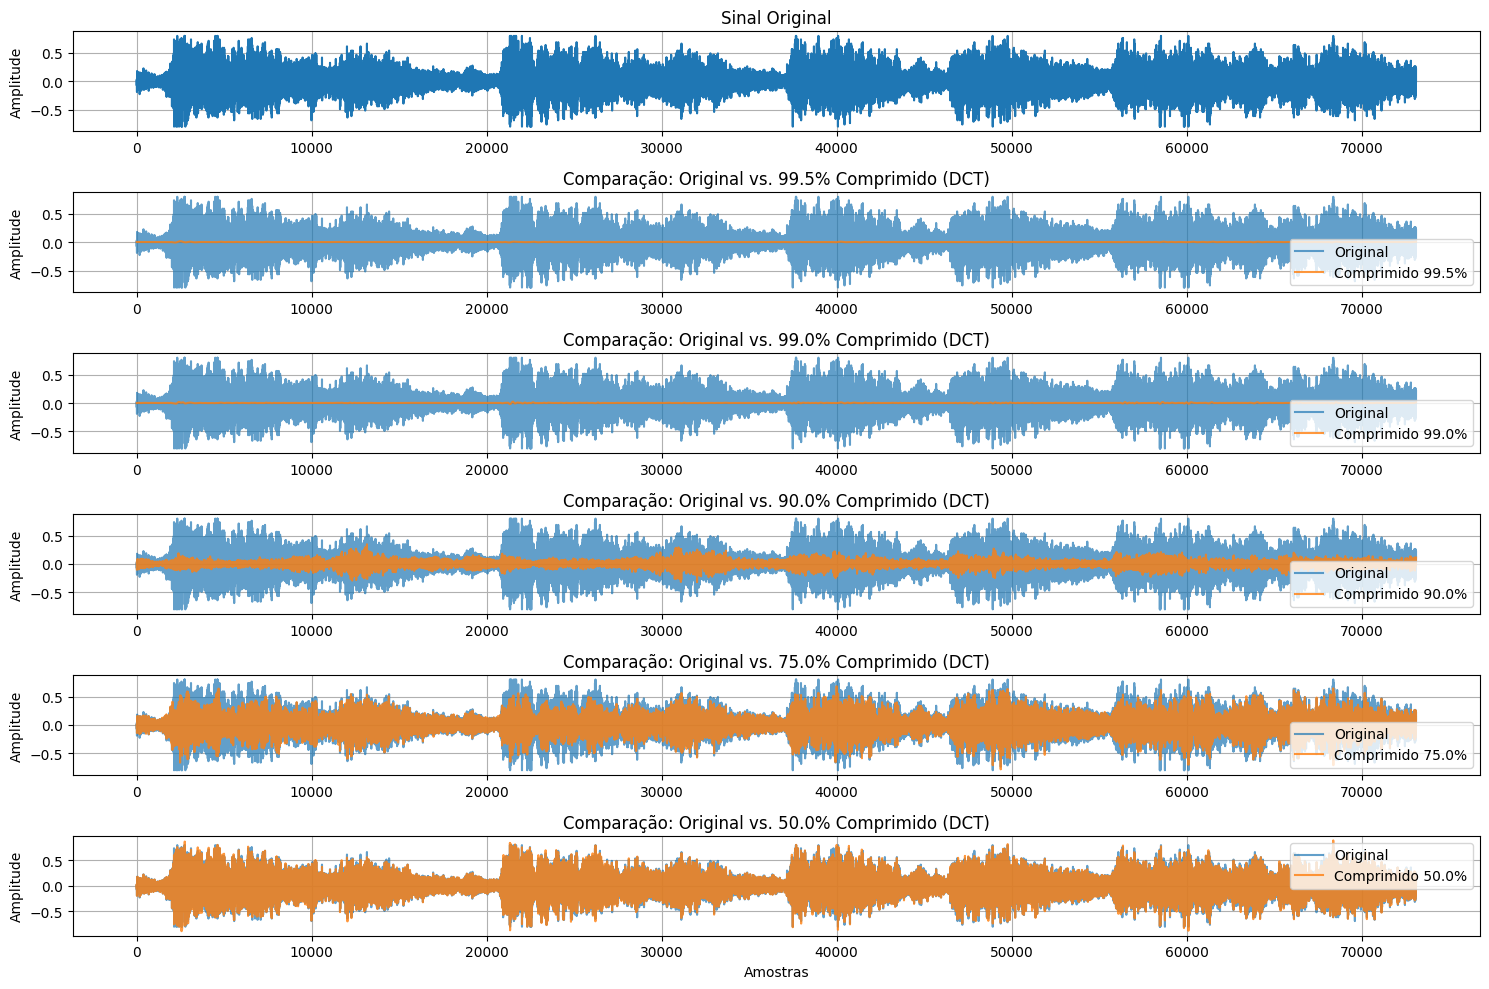


--- Reprodução dos Áudios ---
Áudio Original:



Áudio Comprimido (99.5%):



Áudio Comprimido (99.0%):



Áudio Comprimido (90.0%):



Áudio Comprimido (75.0%):



Áudio Comprimido (50.0%):


In [8]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt
from IPython.display import Audio
# Importar dct e idct da scipy.fftpack
from scipy.fftpack import dct, idct

# --- Funções Auxiliares ---

def compress_dct(signal, compression_percentage):
    """Comprime um sinal usando DCT com base em uma porcentagem de coeficientes."""
    # Aplica a DCT
    signal_dct = dct(signal, type=2, norm='ortho')

    # Calcula o número de coeficientes a manter
    # Para DCT, os coeficientes de baixa frequência estão no início
    num_coefficients_to_keep = int(len(signal_dct) * (100 - compression_percentage) / 100)

    # Cria um array de zeros do mesmo tamanho para os coeficientes comprimidos
    compressed_dct_coeffs = np.zeros_like(signal_dct)

    # Mantém apenas os primeiros coeficientes (baixa frequência)
    compressed_dct_coeffs[:num_coefficients_to_keep] = signal_dct[:num_coefficients_to_keep]

    # Aplica a IDCT para reconstruir o sinal
    compressed_signal = idct(compressed_dct_coeffs, type=2, norm='ortho')
    # A parte real é o sinal reconstruído, pois o sinal original é real
    return compressed_signal.real.astype(signal.dtype), compressed_dct_coeffs

# --- Carregando o arquivo de áudio ---

file_path = '/content/handel.wav'
print(f"Carregando o arquivo de áudio: {file_path}")
samplerate, audio_data = wavfile.read(file_path)

# Normaliza o áudio para float, se necessário, para evitar clipping e para cálculos DCT
# Garante que os dados são convertidos para float para o DCT, mas mantém o tipo original para o IDCT
if audio_data.dtype == np.int16:
    original_audio_float = audio_data.astype(np.float64) / 32768.0
elif audio_data.dtype == np.int32:
    original_audio_float = audio_data.astype(np.float64) / 2147483648.0
else:
    original_audio_float = audio_data.astype(np.float64)

print(f"Taxa de amostragem: {samplerate} Hz")
print(f"Duração do áudio: {len(original_audio_float) / samplerate:.2f} segundos")

# --- Compressão e Comparação ---

compression_percentages = [99.5, 99.0, 90.0, 75.0, 50.0]

compressed_signals = {}
compressed_audio_files = {}

plt.figure(figsize=(15, 10))

# Plot do sinal original
plt.subplot(len(compression_percentages) + 1, 1, 1)
plt.plot(original_audio_float)
plt.title('Sinal Original')
plt.ylabel('Amplitude')
plt.grid(True)

print("\nRealizando compressão e gerando gráficos e áudios:\n")

for i, percentage in enumerate(compression_percentages):
    print(f"Processando compressão de {percentage}%")
    # Usando a função compress_dct
    compressed_signal, compressed_dct_coeffs = compress_dct(original_audio_float, percentage)
    compressed_signals[percentage] = compressed_signal

    # Converte de volta para o tipo de dados original para salvar/reproduzir áudio
    if audio_data.dtype == np.int16:
        # Assegura que os valores estejam dentro dos limites para int16
        compressed_audio_files[percentage] = np.clip((compressed_signal * 32767), -32768, 32767).astype(np.int16)
    elif audio_data.dtype == np.int32:
        compressed_audio_files[percentage] = np.clip((compressed_signal * 2147483647), -2147483648, 2147483647).astype(np.int32)
    else:
        compressed_audio_files[percentage] = compressed_signal

    # Plot do sinal comprimido
    plt.subplot(len(compression_percentages) + 1, 1, i + 2)
    plt.plot(original_audio_float, label='Original', alpha=0.7)
    plt.plot(compressed_signal, label=f'Comprimido {percentage}%', alpha=0.8)
    plt.title(f'Comparação: Original vs. {percentage}% Comprimido (DCT)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)

plt.xlabel('Amostras')
plt.tight_layout()
plt.show()

print("\n--- Reprodução dos Áudios ---")
print("Áudio Original:")
display(Audio(data=audio_data, rate=samplerate))

for percentage in compression_percentages:
    print(f"\nÁudio Comprimido ({percentage}%):")
    display(Audio(data=compressed_audio_files[percentage], rate=samplerate))

### Comparação da Quantidade de Coeficientes para Compressão

Letra b

In [6]:
import pandas as pd

# Número total de coeficientes (tamanho do sinal original)
total_coefficients = len(original_audio_float)
print(f"Número total de coeficientes do sinal original: {total_coefficients}")

results = []

for percentage in compression_percentages:
    # Calcula o número de coeficientes a manter
    num_coefficients_kept = int(total_coefficients * (100 - percentage) / 100)

    # Calcula o número de coeficientes descartados
    num_coefficients_discarded = total_coefficients - num_coefficients_kept

    # Calcula o percentual de coeficientes descartados (compressão real)
    actual_compression_percentage = (num_coefficients_discarded / total_coefficients) * 100

    results.append({
        'Percentual de Compressão Solicitado': f"{percentage:.1f}%",
        'Coeficientes Mantidos': num_coefficients_kept,
        'Coeficientes Descartados': num_coefficients_discarded,
        'Percentual de Coeficientes Descartados (Compressão Real)': f"{actual_compression_percentage:.1f}%"
    })

df_results = pd.DataFrame(results)
display(df_results)

Número total de coeficientes do sinal original: 73113


,Percentual de Compressão Solicitado,Coeficientes Mantidos,Coeficientes Descartados,Percentual de Coeficientes Descartados (Compressão Real)
0,99.5%,365,72748,99.5%
1,99.0%,731,72382,99.0%
2,90.0%,7311,65802,90.0%
3,75.0%,18278,54835,75.0%
4,50.0%,36556,36557,50.0%


### Cálculo do Erro Quadrático Médio (MSE)

Letra c

In [7]:
from sklearn.metrics import mean_squared_error

mse_results = []

print("\nCalculando o Erro Quadrático Médio (MSE) para cada compressão:\n")

for percentage in compression_percentages:
    original = original_audio_float
    compressed = compressed_signals[percentage]

    # Certifica-se de que os arrays têm o mesmo comprimento para o cálculo do MSE
    # Isso é importante caso haja pequenas diferenças de arredondamento nos tamanhos
    min_len = min(len(original), len(compressed))
    mse = mean_squared_error(original[:min_len], compressed[:min_len])

    mse_results.append({
        'Percentual de Compressão Solicitado': f"{percentage:.1f}%",
        'MSE (Erro Quadrático Médio)': mse
    })

df_mse = pd.DataFrame(mse_results)
display(df_mse)


Calculando o Erro Quadrático Médio (MSE) para cada compressão:



,Percentual de Compressão Solicitado,MSE (Erro Quadrático Médio)
0,99.5%,0.038496
1,99.0%,0.038491
2,90.0%,0.035245
3,75.0%,0.013636
4,50.0%,0.001555


Questão 2 - letra A

Questão 2 - Letra a (FFT)

Carregando o arquivo de áudio: /content/handel.wav
Taxa de amostragem: 8192 Hz
Duração do áudio: 8.92 segundos

Realizando compressão com FFT e gerando gráficos e áudios:

Processando compressão de 99.5%
Processando compressão de 99.0%
Processando compressão de 90.0%
Processando compressão de 75.0%
Processando compressão de 50.0%


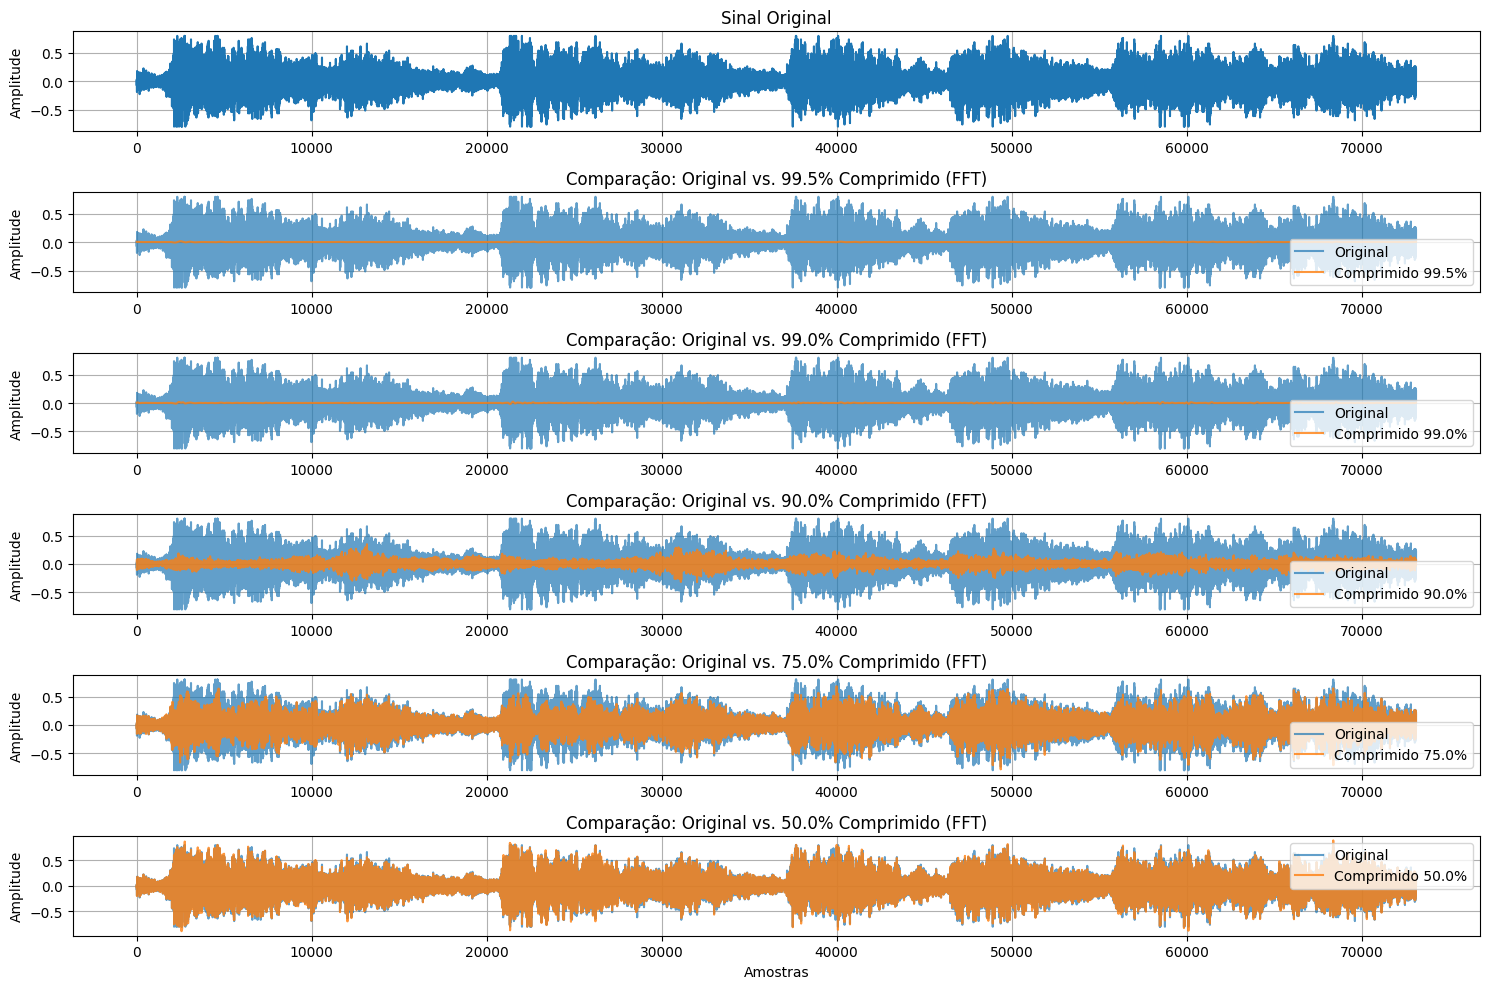


--- Reprodução dos Áudios (FFT) ---
Áudio Original:



Áudio Comprimido (99.5%) (FFT):



Áudio Comprimido (99.0%) (FFT):



Áudio Comprimido (90.0%) (FFT):



Áudio Comprimido (75.0%) (FFT):



Áudio Comprimido (50.0%) (FFT):


In [10]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt
from IPython.display import Audio
# Importar fft e ifft do numpy
from numpy.fft import fft, ifft

# --- Funções Auxiliares ---

def compress_fft(signal, compression_percentage):
    """Comprime um sinal usando FFT com base em uma porcentagem de coeficientes."""
    # Aplica a FFT
    signal_fft = fft(signal)

    # Calcula o número de coeficientes a manter
    # Para FFT, os coeficientes de baixa frequência estão nas extremidades do espectro centralizado
    # e os de alta frequência no meio quando não é feito shift. Vamos manter os primeiros coeficientes.
    num_coefficients = int(len(signal_fft) * (100 - compression_percentage) / 100)

    # Cria um array de zeros do mesmo tamanho
    compressed_fft_coeffs = np.zeros_like(signal_fft)

    # Mantém os coeficientes de baixa frequência no início e no fim do espectro para um sinal real
    compressed_fft_coeffs[:num_coefficients // 2] = signal_fft[:num_coefficients // 2]
    compressed_fft_coeffs[len(signal_fft) - num_coefficients // 2:] = signal_fft[len(signal_fft) - num_coefficients // 2:]

    # Aplica a IFFT para reconstruir o sinal
    compressed_signal = ifft(compressed_fft_coeffs)
    # A parte real é o sinal reconstruído, pois o sinal original é real
    return compressed_signal.real.astype(signal.dtype), compressed_fft_coeffs

# --- Carregando o arquivo de áudio ---

file_path = '/content/handel.wav'
print(f"Carregando o arquivo de áudio: {file_path}")
samplerate, audio_data_fft = wavfile.read(file_path)

# Normaliza o áudio para float, se necessário, para evitar clipping e para cálculos FFT
# Garante que os dados são convertidos para float para o FFT, mas mantém o tipo original para o IFFT
if audio_data_fft.dtype == np.int16:
    original_audio_float_fft = audio_data_fft.astype(np.float64) / 32768.0
elif audio_data_fft.dtype == np.int32:
    original_audio_float_fft = audio_data_fft.astype(np.float64) / 2147483648.0
else:
    original_audio_float_fft = audio_data_fft.astype(np.float64)

print(f"Taxa de amostragem: {samplerate} Hz")
print(f"Duração do áudio: {len(original_audio_float_fft) / samplerate:.2f} segundos")

# --- Compressão e Comparação ---

compression_percentages_fft = [99.5, 99.0, 90.0, 75.0, 50.0]

compressed_signals_fft = {}
compressed_audio_files_fft = {}

plt.figure(figsize=(15, 10))

# Plot do sinal original
plt.subplot(len(compression_percentages_fft) + 1, 1, 1)
plt.plot(original_audio_float_fft)
plt.title('Sinal Original')
plt.ylabel('Amplitude')
plt.grid(True)

print("\nRealizando compressão com FFT e gerando gráficos e áudios:\n")

for i, percentage in enumerate(compression_percentages_fft):
    print(f"Processando compressão de {percentage}%")
    # Usando a função compress_fft
    compressed_signal_fft, compressed_fft_coeffs = compress_fft(original_audio_float_fft, percentage)
    compressed_signals_fft[percentage] = compressed_signal_fft

    # Converte de volta para o tipo de dados original para salvar/reproduzir áudio
    if audio_data_fft.dtype == np.int16:
        # Assegura que os valores estejam dentro dos limites para int16
        compressed_audio_files_fft[percentage] = np.clip((compressed_signal_fft * 32767), -32768, 32767).astype(np.int16)
    elif audio_data_fft.dtype == np.int32:
        compressed_audio_files_fft[percentage] = np.clip((compressed_signal_fft * 2147483647), -2147483648, 2147483647).astype(np.int32)
    else:
        compressed_audio_files_fft[percentage] = compressed_signal_fft

    # Plot do sinal comprimido
    plt.subplot(len(compression_percentages_fft) + 1, 1, i + 2)
    plt.plot(original_audio_float_fft, label='Original', alpha=0.7)
    plt.plot(compressed_signal_fft, label=f'Comprimido {percentage}%', alpha=0.8)
    plt.title(f'Comparação: Original vs. {percentage}% Comprimido (FFT)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)

plt.xlabel('Amostras')
plt.tight_layout()
plt.show()

print("\n--- Reprodução dos Áudios (FFT) ---")
print("Áudio Original:")
display(Audio(data=audio_data_fft, rate=samplerate))

for percentage in compression_percentages_fft:
    print(f"\nÁudio Comprimido ({percentage}%) (FFT):")
    display(Audio(data=compressed_audio_files_fft[percentage], rate=samplerate))

### Comparação da Quantidade de Coeficientes para Compressão (FFT)

Letra b (FFT)

In [11]:
import pandas as pd

# Número total de coeficientes (tamanho do sinal original)
total_coefficients_fft = len(original_audio_float_fft)
print(f"Número total de coeficientes do sinal original: {total_coefficients_fft}")

results_fft = []

for percentage in compression_percentages_fft:
    # Calcula o número de coeficientes a manter
    # Para FFT, mantemos os coeficientes de baixa frequência no início e no fim do espectro
    num_coefficients_kept_fft = int(total_coefficients_fft * (100 - percentage) / 100)

    # Calcula o número de coeficientes descartados
    num_coefficients_discarded_fft = total_coefficients_fft - num_coefficients_kept_fft

    # Calcula o percentual de coeficientes descartados (compressão real)
    actual_compression_percentage_fft = (num_coefficients_discarded_fft / total_coefficients_fft) * 100

    results_fft.append({
        'Percentual de Compressão Solicitado': f"{percentage:.1f}%",
        'Coeficientes Mantidos': num_coefficients_kept_fft,
        'Coeficientes Descartados': num_coefficients_discarded_fft,
        'Percentual de Coeficientes Descartados (Compressão Real)': f"{actual_compression_percentage_fft:.1f}%"
    })

df_results_fft = pd.DataFrame(results_fft)
display(df_results_fft)

Número total de coeficientes do sinal original: 73113


,Percentual de Compressão Solicitado,Coeficientes Mantidos,Coeficientes Descartados,Percentual de Coeficientes Descartados (Compressão Real)
0,99.5%,365,72748,99.5%
1,99.0%,731,72382,99.0%
2,90.0%,7311,65802,90.0%
3,75.0%,18278,54835,75.0%
4,50.0%,36556,36557,50.0%


### Cálculo do Erro Quadrático Médio (MSE) (FFT)

Letra c (FFT)

In [12]:
from sklearn.metrics import mean_squared_error

mse_results_fft = []

print("\nCalculando o Erro Quadrático Médio (MSE) para cada compressão FFT:\n")

for percentage in compression_percentages_fft:
    original = original_audio_float_fft
    compressed = compressed_signals_fft[percentage]

    # Certifica-se de que os arrays têm o mesmo comprimento para o cálculo do MSE
    min_len = min(len(original), len(compressed))
    mse = mean_squared_error(original[:min_len], compressed[:min_len])

    mse_results_fft.append({
        'Percentual de Compressão Solicitado': f"{percentage:.1f}%",
        'MSE (Erro Quadrático Médio)': mse
    })

df_mse_fft = pd.DataFrame(mse_results_fft)
display(df_mse_fft)


Calculando o Erro Quadrático Médio (MSE) para cada compressão FFT:



,Percentual de Compressão Solicitado,MSE (Erro Quadrático Médio)
0,99.5%,0.038496
1,99.0%,0.038491
2,90.0%,0.035245
3,75.0%,0.013636
4,50.0%,0.001555


Letra D - comentário no documento (FFT)